In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print ("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
df = pd.read_csv('/content/sample_data/Ecommerce_Sales_Data_2024_2025.csv')

df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


In [ ]:
# How many rows and columns do we have?
print("Shape:", df.shape)

# What are the column names and data types?
print("\nColumn Info:")
print(df.dtypes)

# Are there any missing values?
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (5000, 14)

Column Info:
Order ID           int64
Order Date        object
Customer Name     object
Region            object
City              object
Category          object
Sub-Category      object
Product Name      object
Quantity           int64
Unit Price         int64
Discount           int64
Sales            float64
Profit           float64
Payment Mode      object
dtype: object

Missing Values:
Order ID         0
Order Date       0
Customer Name    0
Region           0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Unit Price       0
Discount         0
Sales            0
Profit           0
Payment Mode     0
dtype: int64


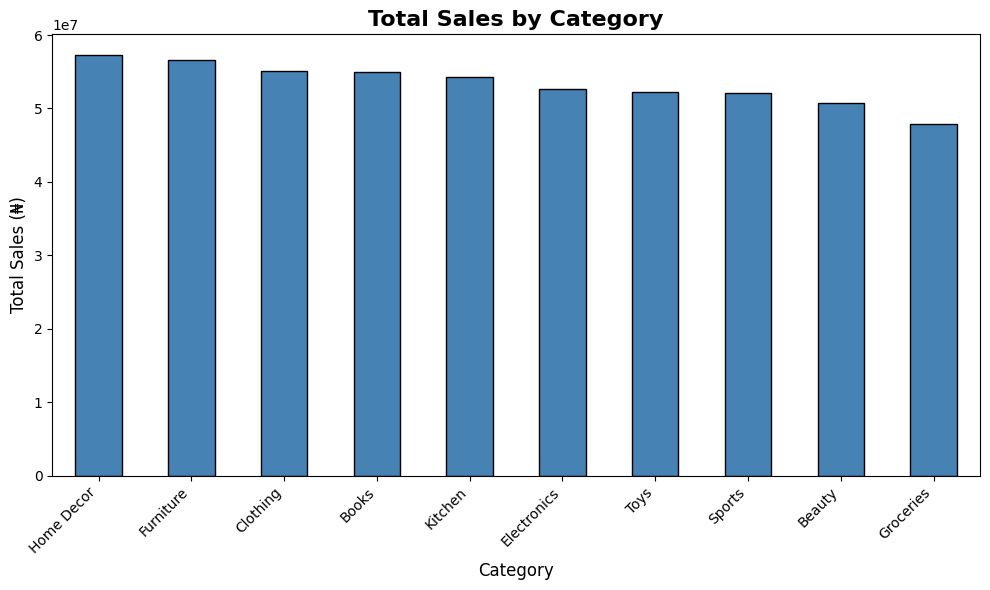

In [ ]:
# Group data by Category and sum the Sales
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Plot the chart
plt.figure(figsize=(10, 6))
category_sales.plot(kind='bar', color='steelblue', edgecolor='black')

# Label the chart
plt.title('Total Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales (₦)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

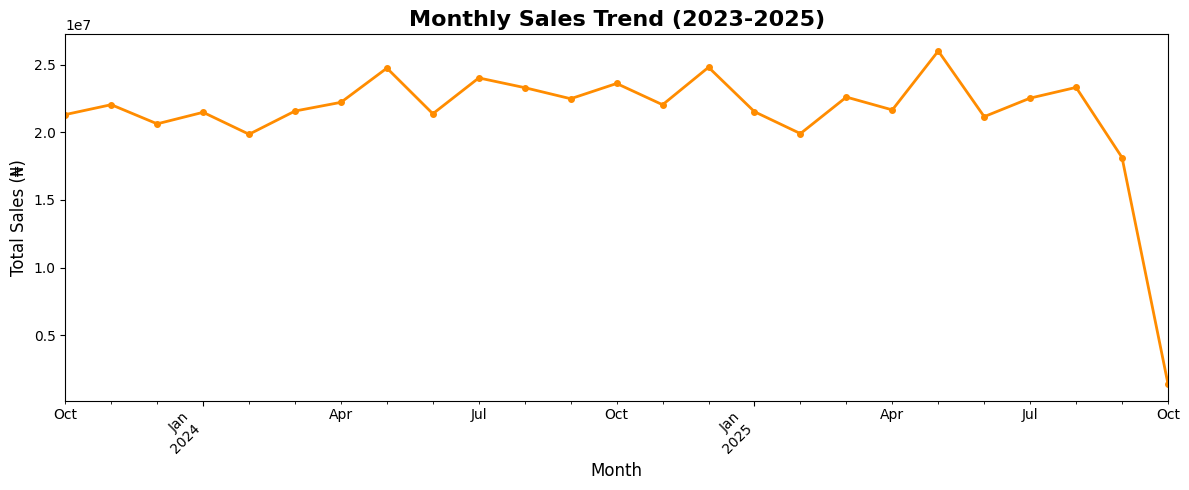

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
# Extract month and year from Order Date
df['Month'] = df['Order Date'].dt.to_period('M')

# Group by Month and sum Sales
monthly_sales = df.groupby('Month')['Sales'].sum()

# chart laabel
plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', color='darkorange', linewidth=2, marker='o', markersize=4)

# chart plot
plt.title('Monthly Sales Trend (2023-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales (₦)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

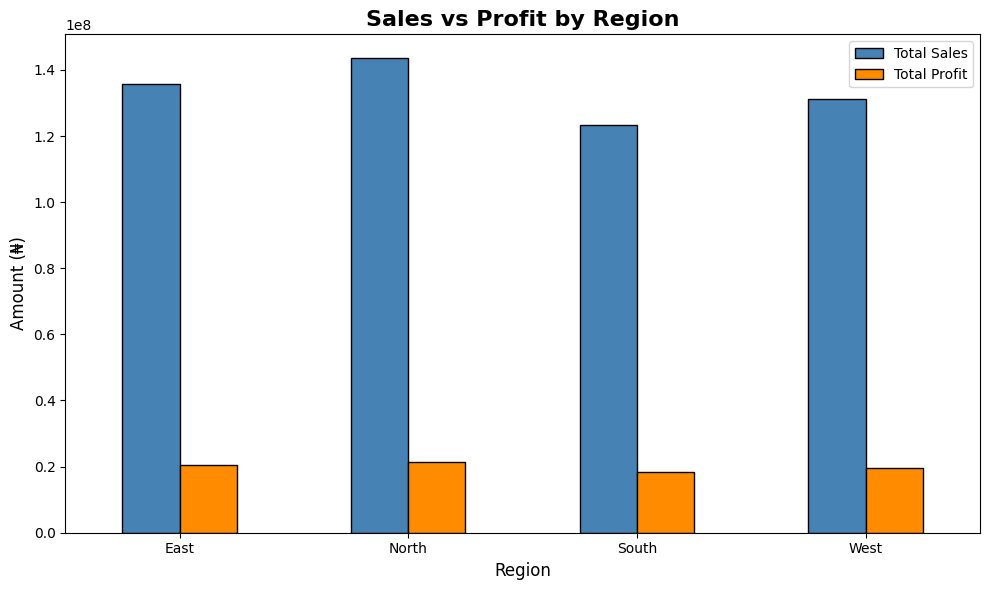

In [12]:
# Group by Region and sum both Sales and Profit
regional = df.groupby('Region')[['Sales', 'Profit']].sum()

# chart plot
plt.figure(figsize=(10, 6))
regional.plot(kind='bar', color=['steelblue', 'darkorange'],
              edgecolor='black', figsize=(10, 6))

# chart label
plt.title('Sales vs Profit by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Amount (₦)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Total Sales', 'Total Profit'])
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

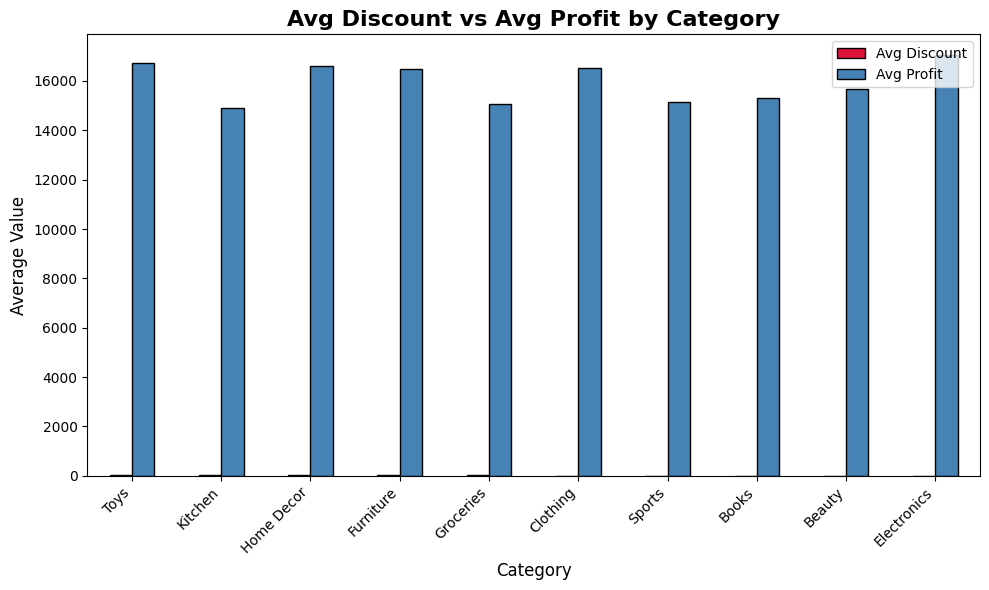

In [13]:
# Average Discount and Profit by Category
disc_profit = df.groupby('Category')[['Discount', 'Profit']].mean().sort_values('Discount', ascending=False)

plt.figure(figsize=(10, 6))
disc_profit.plot(kind='bar', color=['crimson', 'steelblue'], edgecolor='black', figsize=(10, 6))
plt.title('Avg Discount vs Avg Profit by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Average Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(['Avg Discount', 'Avg Profit'])
plt.tight_layout()
plt.show()

In [14]:
# Key business metrics
total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = len(df)
profit_margin = (total_profit / total_revenue) * 100

print("=" * 40)
print("   BUSINESS PERFORMANCE SUMMARY")
print("=" * 40)
print(f"Total Revenue:   ₦{total_revenue:,.0f}")
print(f"Total Profit:    ₦{total_profit:,.0f}")
print(f"Total Orders:    {total_orders:,}")
print(f"Profit Margin:   {profit_margin:.1f}%")
print("=" * 40)

   BUSINESS PERFORMANCE SUMMARY
Total Revenue:   ₦533,666,024
Total Profit:    ₦79,708,735
Total Orders:    5,000
Profit Margin:   14.9%
